In [1]:
import uproot
import vector
import matplotlib.pyplot as plt
import tqdm
import numpy as np

In [18]:
sig = uproot.open("tag_1_pythia8_events_delphes.root")['Delphes']

sig.keys()

['Event',
 'Event/Event.fUniqueID',
 'Event/Event.fBits',
 'Event/Event.Number',
 'Event/Event.ReadTime',
 'Event/Event.ProcTime',
 'Event/Event.ProcessID',
 'Event/Event.MPI',
 'Event/Event.Weight',
 'Event/Event.CrossSection',
 'Event/Event.CrossSectionError',
 'Event/Event.Scale',
 'Event/Event.AlphaQED',
 'Event/Event.AlphaQCD',
 'Event/Event.ID1',
 'Event/Event.ID2',
 'Event/Event.X1',
 'Event/Event.X2',
 'Event/Event.ScalePDF',
 'Event/Event.PDF1',
 'Event/Event.PDF2',
 'Event_size',
 'Weight',
 'Weight/Weight.fUniqueID',
 'Weight/Weight.fBits',
 'Weight/Weight.Weight',
 'Weight_size',
 'Particle',
 'Particle/Particle.fUniqueID',
 'Particle/Particle.fBits',
 'Particle/Particle.PID',
 'Particle/Particle.Status',
 'Particle/Particle.IsPU',
 'Particle/Particle.M1',
 'Particle/Particle.M2',
 'Particle/Particle.D1',
 'Particle/Particle.D2',
 'Particle/Particle.Charge',
 'Particle/Particle.Mass',
 'Particle/Particle.E',
 'Particle/Particle.Px',
 'Particle/Particle.Py',
 'Particle/Parti

In [3]:
def compute_mass(pt1,pt2,eta1,eta2,phi1,phi2,mass1,mass2):
    j1 = vector.obj(pt=pt1, eta=eta1, phi=phi1, mass=mass1)
    j2 = vector.obj(pt=pt2, eta=eta2, phi=phi2, mass=mass2)

    candidate = j1+j2

    return candidate.mass, candidate.pt

In [42]:
pt = sig['GenJet/GenJet.PT'].array()
eta = sig['GenJet/GenJet.Eta'].array()
phi = sig['GenJet/GenJet.Phi'].array()
mass = sig['GenJet/GenJet.Mass'].array()
flavor = sig['GenJet/GenJet.Flavor'].array()
parts = sig['GenJet/GenJet.Constituents'].array()
all_parts = sig['Particle/Particle.PID'].array()

#print(parts[1,0])
print(all_parts[1,:])

[21, 21, 43, 22, 22, 42, 43, 41, 44, 44, 41, ..., 1, 1, 1, 1, 1, 2, 1, 1, 1, 1]


In [8]:
masses = []
for i in tqdm.tqdm(range(5000)):
    masses.append(compute_mass(pt[i,0],pt[i,1],eta[i,0],eta[i,1],phi[i,0],phi[i,1],mass[i,0],mass[i,1])[0])
    
masses = np.array(masses)
masses.shape

100%|██████████| 5000/5000 [00:07<00:00, 641.95it/s]


(5000,)

(array([  6.,   8.,   8.,  15.,  23.,  69., 198.,  26.,  32.,  44.,  67.,
         63.,  77.,  68.,  78.,  90., 100., 104., 105., 114., 126., 101.,
        121., 120.]),
 array([ 80. ,  87.5,  95. , 102.5, 110. , 117.5, 125. , 132.5, 140. ,
        147.5, 155. , 162.5, 170. , 177.5, 185. , 192.5, 200. , 207.5,
        215. , 222.5, 230. , 237.5, 245. , 252.5, 260. ]),
 [<matplotlib.patches.Polygon at 0x7fad925b0110>])

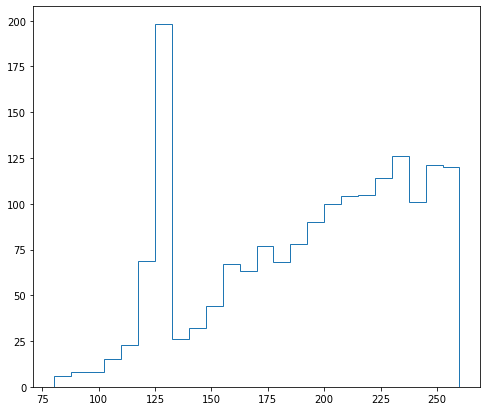

In [17]:
fig,ax = plt.subplots(figsize=(8,7))
plt.hist(masses,bins=np.linspace(80,260,25),histtype='step',label='DiJet Mass')
#plt.show()